# My First Data Analysis - Titanic Dataset 🚢

### What we'll do:
1. Load data from a file
2. Look at the data
3. Make simple charts
4. Find interesting patterns

### Before starting:
- Click **"Add Data"** on the right
- Search for **"Titanic"**
- Add **"Titanic - Machine Learning from Disaster"**

---
## Part 1: Setting Up Our Tools

Think of this like getting your art supplies before painting. We need some tools to work with data.

In [1]:
# Import our tools (libraries)
# pandas = works with data like Excel
# matplotlib = makes charts and graphs
# seaborn = makes prettier charts

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## Part 2: Loading Our Data

Let's open our data file. It's like opening an Excel spreadsheet.

In [2]:
# Load the data from the file
data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

print("We have", len(data), "passengers in our data")

We have 891 passengers in our data


---
## Part 3: First Look at the Data

Let's see what our data looks like. We'll look at the first 5 rows.

In [3]:
# Show the first 5 rows
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Column Descriptions

- **PassengerId**: Unique identifier assigned to each passenger.
- **Survived**: Survival status (0 = Did not survive, 1 = Survived).
- **Pclass**: Passenger ticket class (1 = First class, 2 = Second class, 3 = Third class).
- **Name**: Full name of the passenger including title (Mr., Mrs., Miss, etc.).
- **Sex**: Gender of the passenger.
- **Age**: Age of the passenger in years.
- **SibSp**: Number of siblings or spouses aboard the Titanic.
- **Parch**: Number of parents or children aboard the Titanic.
- **Ticket**: Ticket number assigned to the passenger.
- **Fare**: Amount paid for the ticket.
- **Cabin**: Cabin number where the passenger stayed (may contain missing values).
- **Embarked**: The port (city) where the passenger got on the Titanic
  - C = Cherbourg  
  - Q = Queenstown  
  - S = Southampton

In [4]:
# Let's see all the column names
print("Our columns are:")
print(data.columns.tolist())

Our columns are:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


---
## Part 4: Basic Information

Let's get some basic facts about our data.

In [5]:
data.shape

(891, 12)

In [6]:
# How many rows and columns?
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 891
Number of columns: 12


In [7]:
# Get simple statistics
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Reading the table above:
- **count** = how many values we have
- **mean** = average
- **min** = smallest value
- **max** = largest value

---
## Part 5: Missing Data

Sometimes data is missing (like empty cells in Excel). Let's find out where.

In [8]:
data.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
# Count missing values in each column
missing = data.isnull().sum()

print("Missing values in each column:")
print(missing)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Notice:** Age has 177 missing values. That means we don't know the age for 177 passengers.

---
## Part 6: Who Survived?

This is the most important question! Let's find out how many people survived.

In [10]:
# Count survivors
survived_count = data['Survived'].sum()  # sum of 1s = number who survived
died_count = len(data) - survived_count

print("Survived:", survived_count, "people")
print("Died:", died_count, "people")

Survived: 342 people
Died: 549 people


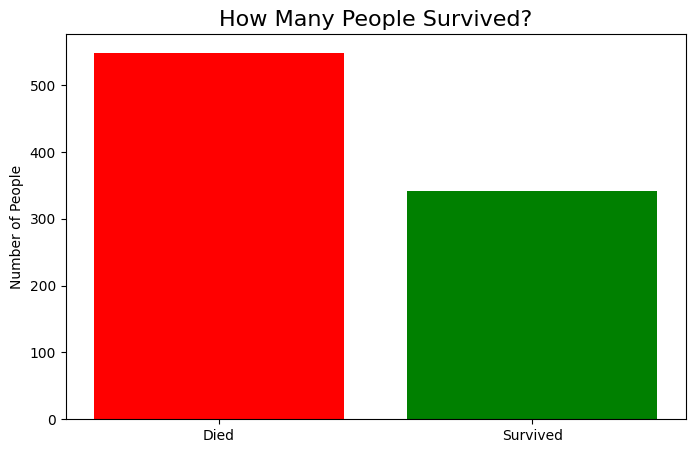

In [11]:
# Make a simple bar chart
survival_counts = data['Survived'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(['Died', 'Survived'], survival_counts, color=['red', 'green'])
plt.title('How Many People Survived?', fontsize=16)
plt.ylabel('Number of People')
plt.show()

---
## Part 7: Men vs Women

Did more men or women survive? Let's find out!

In [12]:
# Count men and women
gender_count = data['Sex'].value_counts()
print("Number of males:", gender_count['male'])
print("Number of females:", gender_count['female'])

Number of males: 577
Number of females: 314


In [13]:
# How many men survived? How many women survived?
male_survived = data[data['Sex'] == 'male']['Survived'].sum()
female_survived = data[data['Sex'] == 'female']['Survived'].sum()

print("Men who survived:", male_survived)
print("Women who survived:", female_survived)

Men who survived: 109
Women who survived: 233


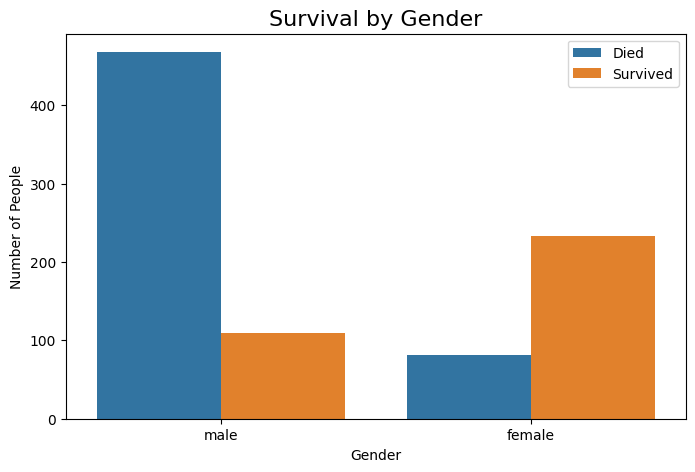

In [14]:
# Make a chart
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Sex', hue='Survived')
plt.title('Survival by Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Number of People')
plt.legend(['Died', 'Survived'])
plt.show()

### Why did more women survive?
There was a "women and children first" policy when loading the lifeboats!

---
## Part 8: Ticket Class

Did rich people (1st class) survive more than poor people (3rd class)?

In [15]:
# Count people in each class
class_count = data['Pclass'].value_counts()
print("People in each class:")
class_count

People in each class:


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

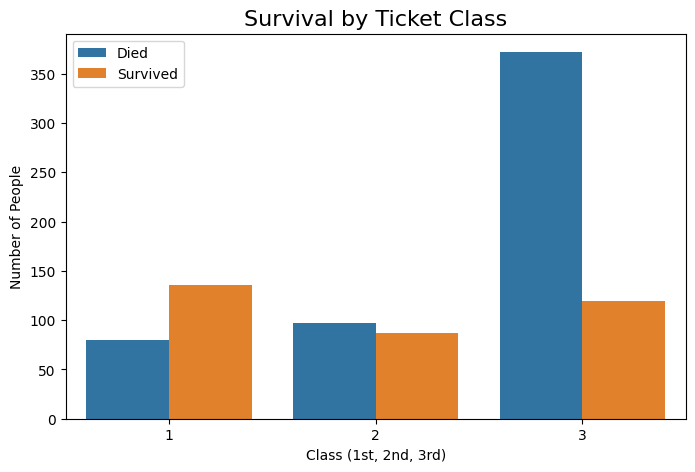

In [16]:
# Make a chart showing survival by class
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Pclass', hue='Survived')
plt.title('Survival by Ticket Class', fontsize=16)
plt.xlabel('Class (1st, 2nd, 3rd)')
plt.ylabel('Number of People')
plt.legend(['Died', 'Survived'])
plt.show()

---
## Part 9: Age Analysis

How old were the passengers? Let's find out!

In [17]:
# Find the youngest and oldest passenger
youngest = data['Age'].min()
oldest = data['Age'].max()
average_age = data['Age'].mean()

print("Youngest passenger:", youngest, "years old")
print("Oldest passenger:", oldest, "years old")
print("Average age:", average_age, "years old // or ", round(average_age, 1))

Youngest passenger: 0.42 years old
Oldest passenger: 80.0 years old
Average age: 29.69911764705882 years old // or  29.7


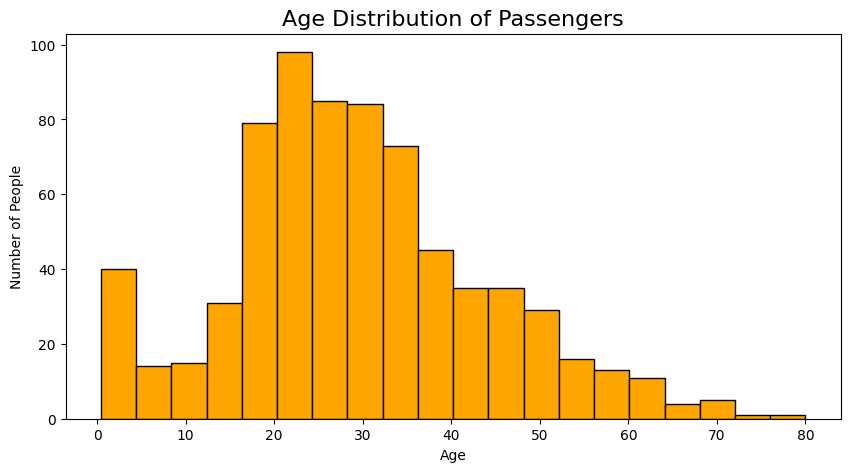

In [28]:
# Make a histogram (shows how many people of each age)
plt.figure(figsize=(10, 5))
plt.hist(data['Age'].dropna(), bins=20, color='orange', edgecolor='black')
plt.title('Age Distribution of Passengers', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.show()

---
## Part 10: Ticket Prices

How much did people pay for their tickets?

In [19]:
# Find ticket prices
cheapest = data['Fare'].min()
most_expensive = data['Fare'].max()
average_fare = data['Fare'].mean()

print("Cheapest ticket: $", round(cheapest, 2))
print("Most expensive ticket: $", round(most_expensive, 2))
print("Average ticket price: $", round(average_fare, 2))

Cheapest ticket: $ 0.0
Most expensive ticket: $ 512.33
Average ticket price: $ 32.2


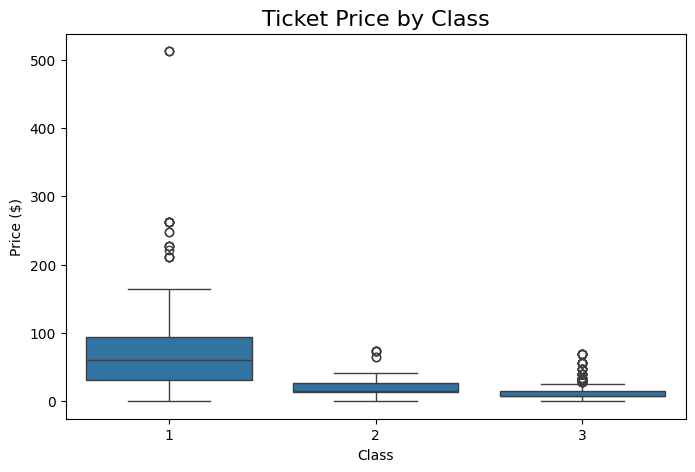

In [20]:
# Compare ticket prices by class
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Pclass', y='Fare')
plt.title('Ticket Price by Class', fontsize=16)
plt.xlabel('Class')
plt.ylabel('Price ($)')
plt.show()

### How to read a box plot:
- The line in the middle = average price
- The box = where most prices are
- The dots = unusual prices (very cheap or very expensive)

---
## Part 11: Family Size

Were people traveling alone or with family?

In [31]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


In [33]:
data['FamilySize'] = data['SibSp'] + data['Parch'] +1

# Count people traveling alone
alone = len(data[data['FamilySize'] == 1])
with_family = len(data[data['FamilySize'] > 1])

print("Traveling alone:", alone, "people")
print("Traveling with family:", with_family, "people")

Traveling alone: 537 people
Traveling with family: 354 people


In [36]:
data['FamilySize'].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [39]:
family_sizes.values

array([537, 161, 102,  29,  15,  22,  12,   6,   7])

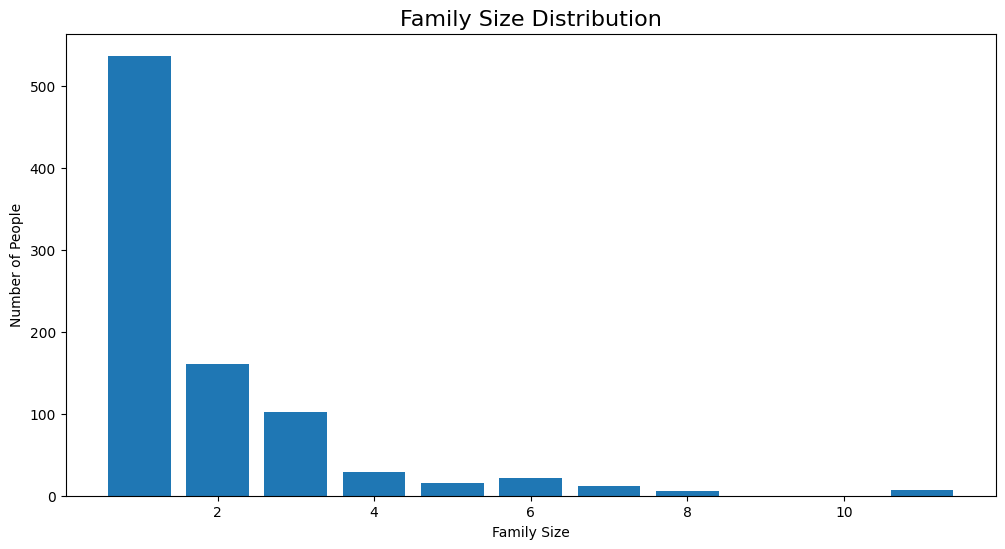

In [41]:
# Make a simple chart
plt.figure(figsize=(12, 6))

family_sizes = data['FamilySize'].value_counts().sort_index()
plt.bar(family_sizes.index, family_sizes.values)


plt.title('Family Size Distribution', fontsize=16)
plt.xlabel('Family Size')
plt.ylabel('Number of People')
plt.show()

---
## Part 13: Practice Exercises 💪

### Easy Exercises:
1. Find how many children (age < 12) were on the Titanic
2. Calculate the average fare for 2nd class passengers
3. Count how many people embarked from each port (Embarked column)

### Try This:

In [23]:
# Exercise 1: Count children (age < 12)
# Hint: use data[data['Age'] < 12]

# YOUR CODE HERE



In [24]:
# Exercise 2: Average fare for 2nd class
# Hint: filter data where Pclass == 2, then get mean of Fare

# YOUR CODE HERE


In [25]:
# Exercise 3: Count passengers by embarkation port
# Hint: use value_counts() on the Embarked column

# YOUR CODE HERE


---
## Quick Reference Guide 📖

Here are the most important commands you learned:

```python
# Load data
data = pd.read_csv('filename.csv')

# Look at data
data.head()          # First 5 rows
data.tail()          # Last 5 rows
data.shape           # Number of rows and columns

# Get information
data['column'].sum()        # Add up all values
data['column'].mean()       # Average
data['column'].min()        # Smallest value
data['column'].max()        # Largest value
data['column'].value_counts()  # Count each unique value

# Filter data
data[data['column'] == value]    # Get rows where column equals value
data[data['column'] > value]     # Get rows where column is greater than value

# Missing values
data.isnull().sum()    # Count missing values

# Make charts
plt.bar(x, y)                      # Bar chart
plt.hist(data)                     # Histogram
sns.countplot(data=data, x='column')  # Count plot
sns.boxplot(data=data, x='column')    # Box plot
```